In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import animation
from IPython.display import HTML

from joblib import Parallel, delayed

In [2]:
def Hamiltonian(L, J0, Delta, A, V, g):

    H = np.zeros((2 * L, 2 * L), dtype=complex)
    
    # --- Sample --- #

    for i in range(L):
        H[i, (i + 1) % L] = -J0 * np.exp(1j * A)
        H[(i + 1) % L, i] = -J0 * np.exp(-1j * A)
        
        if i % 2 == 0:
            H[i, i] = Delta
        else:
            H[i, i] = -Delta

    # --- Probe --- #

    for i in range(L):
        
        H[i + L, i + L] = V

    # --- Coupling --- #
    
    for i in range(L):
        H[i, i + L] = g
        H[i + L, i] = g

    return H

def H0(L, J0, Delta):

    H = np.zeros((L, L), dtype=complex)
    
    # --- Sample --- #

    for i in range(L):
        H[i, (i + 1) % L] = -J0 
        H[(i + 1) % L, i] = -J0
        
        if i % 2 == 0:
            H[i, i] = Delta
        else:
            H[i, i] = -Delta
            
    return H

def C0(L, J0, Delta, N_occ):

    H = H0(L, J0, Delta)
    eigvals, eigvecs = np.linalg.eigh(H)

    # Occupy the lowest N_occ states
    occupied_states = eigvecs[:, :N_occ]

    # Construct the correlation matrix
    C_0 = occupied_states @ occupied_states.conj().T
    
    return C_0

def simulation(C0, A, Probe, J0, Delta, V, times):

    L = C0.shape[0]

    C_ij = np.zeros((2*L, 2*L, len(times)), dtype=complex) 

    C_ij[:, :, 0] = np.block([[C0, np.zeros((L, L))], [np.zeros((L, L)), np.zeros((L, L))]])
        
    for t in range(1, len(times)):
            
        dt = times[t] - times[t-1]
            
        H = Hamiltonian(L, J0, Delta, A[t], V, g=Probe[t])

        eigvals, eigvecs = np.linalg.eigh(H)
        U = eigvecs @ np.diag(np.exp(-1j * eigvals * dt)) @ np.linalg.inv(eigvecs)

        C_ij[:, :, t] = U @ C_ij[:, :, t-1] @ U.conj().T

    return C_ij

def entropy(rho, cut, tol=1e-6):

    rho_cut = rho[:cut, :cut]
    
    eigvals = np.linalg.eigvals(rho_cut)
    eigvals = np.real(eigvals)  # Ensure eigenvalues are real
    
    eigvals = np.clip(eigvals, tol, 1.0)  # Clip eigenvalues to avoid log(0) issues

    S = -np.sum(eigvals * np.log(eigvals))
    return S

def Green_function(psi_occ, J0, Delta, A, Probe, w, times):

    L = psi_occ.shape[0]
    N_occ = psi_occ.shape[1]
    N_t = times.shape[0]

    psi_t = np.zeros((2*L, N_occ, N_t), dtype=complex)

    psi_t[:L, :, 0] = psi_occ

    G_ij = np.zeros((2*L, 2*L, N_t), dtype=complex)

    G_ij[:, :, 0] = psi_t[:, :, 0] @ psi_t[:, :, 0].conj().T

    for t in range(1, N_t):

        dt = times[t] - times[t-1]

        H_t = Hamiltonian(L, J0, Delta, A[t], V=w, g=Probe[t])

        eigvals_t, eigvecs_t = np.linalg.eigh(H_t)

        U = eigvecs_t @ np.diag(np.exp(-1j * eigvals_t * dt)) @ eigvecs_t.conj().T

        psi_t[:, :, t] = U @ psi_t[:, :, t-1]

        G_ij[:, :, t] = psi_t[:, :, t] @ psi_t[:, :, 1].conj().T

    return G_ij

def folding(n_w_t_k, k, a):
    
    N_omega, N_t, N_k = n_w_t_k.shape

    fold_param = np.pi / a
    n_w_t_k_folded = np.zeros((N_omega, N_t, N_k), dtype=float)

    # Fold k values into the first Brillouin zone #
    
    k_folded = (k + fold_param) % (2 * fold_param) - fold_param 

    # Find index of folded k matching original k and populates n_w_t_k_folded #

    for i in range(len(k)):
        target = np.argmin(np.abs(k - k_folded[i]))
        n_w_t_k_folded[:, :, target] += n_w_t_k[:, :, i] 

    # Crop k axis (remove indeces outside 1st Brillouin zone) #

    k_idx = np.where(np.max(n_w_t_k_folded[:, -1, :], axis=0) > 1e-6)[0] # Check which k values have non-zero spectral weight
    kmin = k_idx[0] # Define min cutoff
    kmax = k_idx[-1] # Define max cutoff

    k_folded = k_folded[kmin:kmax+1] # Crop k axis 

    n_w_t_k_folded = n_w_t_k_folded[:, :, kmin:kmax+1] # Crop n_w_t_k_folded

    return k_folded, n_w_t_k_folded

def visualise_matrix(H, cmap='Greys', figsize=(12,5)):
    # Construct subplots for real and imaginary parts of Hamiltonian matrix
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Real part
    im_real = axes[0].imshow(H.real, cmap=cmap)
    axes[0].set_title('Real Part')
    axes[0].set_xlabel('Column')
    axes[0].set_ylabel('Row')
    plt.colorbar(im_real, ax=axes[0])
    
    # Imaginary part
    im_imag = axes[1].imshow(H.imag, cmap=cmap)
    axes[1].set_title('Imaginary Part')
    axes[1].set_xlabel('Column')
    axes[1].set_ylabel('Row')
    plt.colorbar(im_imag, ax=axes[1])
    
    fig.suptitle('Matrix visualization for (16x16) Hamiltonian')
    plt.show()

In [3]:
L = 64

N_t = 200
times = np.linspace(0.0, 20.0, N_t)

N_omega = 100
omega_scan = np.linspace(-5.0, 5.0, N_omega)

J0 = 1.0
Delta = 0.0

P0 = 0.3
t_probe = 10.0
sigma = 2.0


Probe = P0 * np.exp(-(times - t_probe)**2 / (sigma**2))

In [5]:
A0 = 2.0

omega_vals = np.linspace(0, 5, 6)

S_t = np.zeros((len(omega_vals), len(omega_scan), len(times)))

for i, wi in enumerate(omega_vals):

    A = A0 * np.sin(wi * times)
    
    H_0 = H0(L, J0, Delta)
    C_0 = C0(L, J0, Delta, N_occ=L//2)

    C_ij = Parallel(n_jobs=-1, verbose=1)(delayed(simulation)(C_0, A, Probe, J0, Delta, w, times) for w in omega_scan)

    print("Converting to array...")

    C_ij = np.array(C_ij)  # Shape: (N_omega, 2L, 2L, N_t)

    C_probe = C_ij[:, L:, L:, :]  # Shape: (N_omega, L, L, N_t)

    print("C_probe.shape:", C_probe.shape)

    cut = L // 2 

    for ti in range(len(times)):
        for wi in range(N_omega):
            S_t[i, wi, ti] = entropy(C_probe[wi, :, :, ti], cut)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   30.0s finished


Converting to array...
C_probe.shape: (100, 64, 64, 200)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   34.5s finished


Converting to array...
C_probe.shape: (100, 64, 64, 200)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   32.0s finished


...

Converting to array...
C_probe.shape: (100, 64, 64, 200)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   36.9s finished


Converting to array...
C_probe.shape: (100, 64, 64, 200)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   37.1s finished


Converting to array...
C_probe.shape: (100, 64, 64, 200)


C:\Users\lucas\AppData\Local\Temp\ipykernel_12548\629794539.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


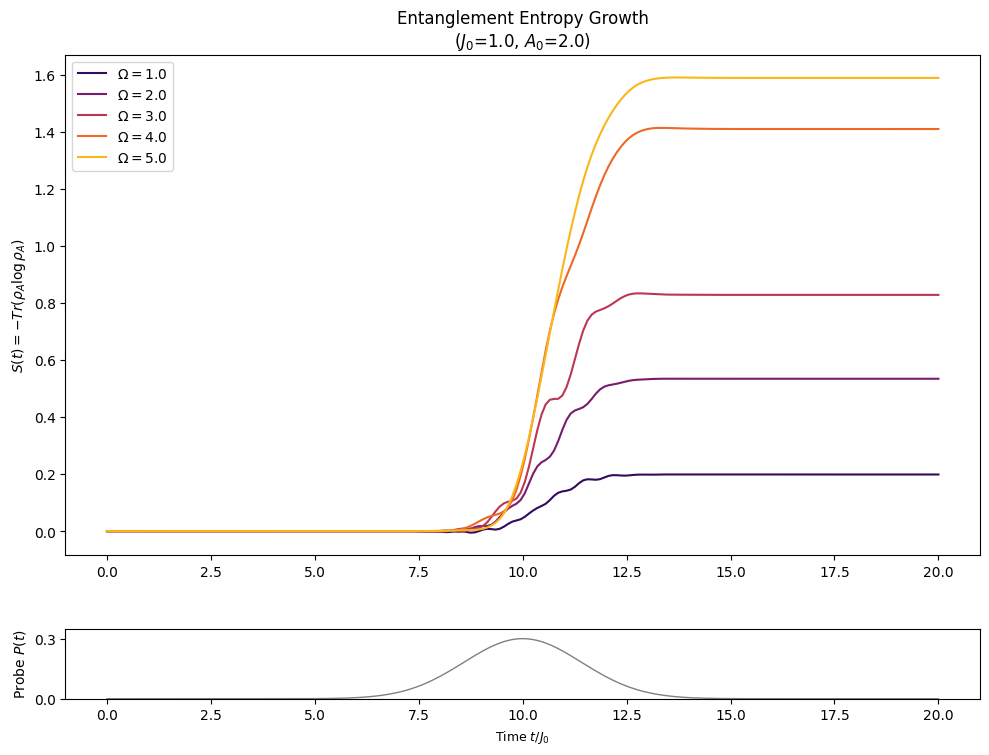

In [26]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Plotting entanglement entropy as a function of time for different frequencies #
plt.figure(figsize=(10, 6))
ax_main = plt.gca()

for i in range(len(omega_vals)):
       if i != 0:
              plt.plot(times, np.mean(S_t[6-i, :, :] - S_t[0, :, :], axis=0), color=plt.cm.inferno(i/len(omega_vals)), label=r'$\Omega={}$'.format(np.round(omega_vals[i], 3)))

plt.title(r'Entanglement Entropy Growth' + '\n' + r'($J_0$={}, $A_0$={:.1f})'.format(J0, A0))
plt.ylabel(r'$S(t)=-Tr(\rho_{A} \log \rho_{A})$')
plt.legend(loc='upper left')

# Add inset axes at the bottom showing only the probe pulse
ax_inset = inset_axes(ax_main, width="100%", height="40%", loc='lower center',
                       bbox_to_anchor=(0.0, -0.3, 1.0, 0.35), 
                       bbox_transform=ax_main.transAxes)

ax_inset.plot(times, Probe, color='gray', linewidth=1)
ax_inset.set_xlabel(r'Time $t/J_0$', fontsize=9)
ax_inset.set_ylabel(r'Probe $P(t)$')
ax_inset.set_ylim(0.0, 0.35)
ax_inset.set_yticks([0.0, 0.3])

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Final Entanglement Entropy $S(t_{final})$')

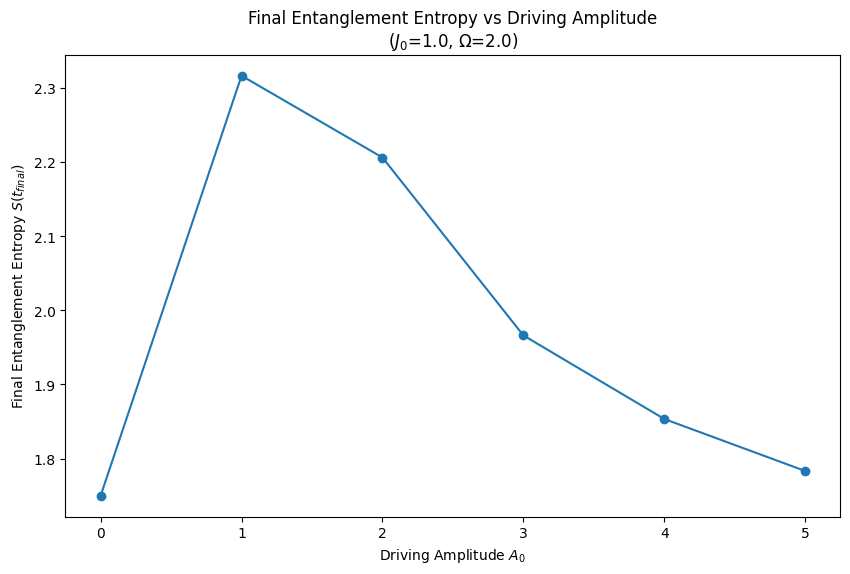

In [114]:
S_final = np.mean(S_t[:, :, -1], axis=1)

plt.figure(figsize=(10, 6))
plt.plot(omega_vals, S_final, marker='o')
plt.title(r'Final Entanglement Entropy vs Driving Amplitude' + '\n' + r'($J_0$={}, $\Omega$={:.1f})'.format(J0, omega))
plt.xlabel(r'Driving Amplitude $A_0$')  
plt.ylabel(r'Final Entanglement Entropy $S(t_{final})$')